In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:


# -------------------------
# Fix PDF image-stream compatibility
# -------------------------
# Prevents some PDF readers from reporting:
# "Insufficient data for an image"
mpl.rcParams["pdf.compression"] = 0


# -------------------------
# Style
# -------------------------
sns.set_theme(style="white", context="paper")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,
    "font.family": "Times New Roman",
})

LINE_COLOR = "#2C3E50"


# -------------------------
# Project paths
# -------------------------
# The Jupyter Notebook working directory should be:
# Code/Figures Python
project_dir = Path.cwd()

data_dir = project_dir / "Data"
results_dir = project_dir / "Results"


# -------------------------
# Input and output paths
# -------------------------
file_xlsx = (
    data_dir
    / "MSA_PFF_top300_CellType_enrichment.xlsx"
)

out_dir = (
    results_dir
    / "MSA_PFF_top300_CellType_enrichment"
    / "Cell_Type"
)

out_dir.mkdir(
    parents=True,
    exist_ok=True
)


def _build_matrix_from_sheet(df, row_order=None):
    """
    Convert one enrichment worksheet into bubble-color and bubble-size
    vectors using the original MATLAB-style transformations.

    Bubble color:
        -log10(FDR) + 1

    Bubble size:
        Enrichment score - 1
    """
    df = df.copy()

    # Remove possible leading or trailing spaces from column names.
    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    # Convert adjusted p values into -log10(FDR) + 1.
    # The lower clipping avoids log10(0).
    fdr = pd.to_numeric(
        df["Adjusted_P_Value"],
        errors="coerce"
    ).clip(lower=1e-300)

    neglog10_fdr_plus1 = (
        -np.log10(fdr) + 1.0
    ).to_numpy()

    # Convert enrichment score into enrichment - 1.
    enrich = pd.to_numeric(
        df["Enrichment_Score"],
        errors="coerce"
    ).to_numpy()

    enrich_minus1 = (
        enrich - 1.0
    )

    cell_types = (
        df["Cell_Type"]
        .astype(str)
        .to_list()
    )

    # Use the supplied shared cell-type order.
    if row_order is None:
        row_order = cell_types

    idx = [
        cell_types.index(cell_type)
        for cell_type in row_order
    ]

    v_color = neglog10_fdr_plus1[idx]
    v_size = enrich_minus1[idx]

    # Negative size values are set to zero,
    # consistent with the original MATLAB logic.
    v_size = np.clip(
        v_size,
        a_min=0,
        a_max=None
    )

    return row_order, v_color, v_size


def plot_special_heatmap_bubble_from_excel(
    file_xlsx,
    out_dir,
    sheet_left="MSA",
    sheet_right="PFF",
    rownames=("MSA", "PFF"),
    save_prefix="CellType_HeatmapBubble_MSA_PFF_horizontal_white2red",
):
    """
    Draw a horizontal bubble heatmap comparing the top-300
    cell-type enrichment results for MSA and PFF.

    Bubble color represents:
        -log10(FDR) + 1

    Bubble size represents:
        Enrichment score - 1

    A black ring indicates:
        FDR < 0.05
    """
    import matplotlib.colors as mcolors
    import matplotlib as mpl
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # -------------------------
    # Light pink to deep-red colormap
    # -------------------------
    white_to_red = mcolors.LinearSegmentedColormap.from_list(
        "pink_to_deepred",
        [
            (0.98, 0.92, 0.92),  # very light pink
            (0.99, 0.80, 0.78),
            (0.97, 0.60, 0.55),
            (0.90, 0.35, 0.28),
            (0.75, 0.00, 0.10),  # deep red
        ],
        N=256
    )

    cmap = white_to_red


    # -------------------------
    # Read MSA and PFF sheets
    # -------------------------
    df_L = pd.read_excel(
        file_xlsx,
        sheet_name=sheet_left
    )

    df_R = pd.read_excel(
        file_xlsx,
        sheet_name=sheet_right
    )

    # Remove possible spaces from column names before accessing them.
    df_L.columns = [
        str(c).strip()
        for c in df_L.columns
    ]

    df_R.columns = [
        str(c).strip()
        for c in df_R.columns
    ]


    # -------------------------
    # Build a shared cell-type order
    # -------------------------
    # Cell types appearing in MSA are listed first, followed by any
    # additional cell types present only in PFF.
    col_order = list(
        dict.fromkeys(
            df_L["Cell_Type"].astype(str).tolist()
            + df_R["Cell_Type"].astype(str).tolist()
        )
    )

    cols, cL, sL = _build_matrix_from_sheet(
        df_L,
        row_order=col_order
    )

    _, cR, sR = _build_matrix_from_sheet(
        df_R,
        row_order=col_order
    )


    # -------------------------
    # Build plotting matrices
    # -------------------------
    # Matrix shape:
    #     2 groups × number of cell types
    C = np.vstack([
        cL,
        cR
    ])

    S = np.vstack([
        sL,
        sR
    ])

    n_rows, n_cols = C.shape


    # -------------------------
    # Bubble-radius mapping
    # -------------------------
    maxEn = np.nanmax(
        np.abs(S)
    )

    if maxEn <= 0 or np.isnan(maxEn):
        maxEn = 1.0

    r_min = 0.08
    r_max = 0.42

    R = (
        r_min
        + (S / maxEn)
        * (r_max - r_min)
    )


    # -------------------------
    # Color normalization
    # -------------------------
    # The theoretical minimum of -log10(FDR) + 1 is 1
    # when FDR = 1.
    vmin = 1.0

    # Use the 95th percentile to reduce distortion from extreme values.
    vmax = np.nanpercentile(
        C,
        95
    )

    if vmax <= vmin:
        vmax = vmin + 1e-6

    norm = mpl.colors.Normalize(
        vmin=vmin,
        vmax=vmax
    )


    # -------------------------
    # Figure layout
    # -------------------------
    # Main bubble heatmap + legend panel + horizontal colorbar.
    fig = plt.figure(
        figsize=(
            0.55 * n_cols + 3.4,
            3.3
        )
    )

    gs = fig.add_gridspec(
        nrows=2,
        ncols=2,
        height_ratios=[
            1.0,
            0.14
        ],
        width_ratios=[
            1.0,
            0.32
        ],
        wspace=0.18,
        hspace=0.25
    )

    ax = fig.add_subplot(
        gs[0, 0]
    )

    ax_leg = fig.add_subplot(
        gs[0, 1]
    )

    cax = fig.add_subplot(
        gs[1, 0]
    )


    # ========================================================
    # Main bubble heatmap
    # ========================================================
    ax.set_facecolor("white")

    ax.set_xlim(
        0.5,
        n_cols + 0.5
    )

    ax.set_ylim(
        0.5,
        n_rows + 0.5
    )

    ax.invert_yaxis()
    ax.set_aspect("equal")

    ax.set_xticks(
        range(1, n_cols + 1)
    )

    ax.set_xticklabels(
        cols,
        rotation=30,
        ha="right"
    )

    ax.set_yticks([
        1,
        2
    ])

    ax.set_yticklabels(
        list(rownames)
    )

    ax.tick_params(
        axis="both",
        direction="out",
        length=3,
        width=0.8
    )


    # -------------------------
    # Grid lines
    # -------------------------
    for y in np.arange(
        0.5,
        n_rows + 1.5,
        1.0
    ):
        ax.plot(
            [0.5, n_cols + 0.5],
            [y, y],
            color=[0.85, 0.85, 0.85],
            lw=0.8,
            zorder=0
        )

    for x in np.arange(
        0.5,
        n_cols + 1.5,
        1.0
    ):
        ax.plot(
            [x, x],
            [0.5, n_rows + 0.5],
            color=[0.85, 0.85, 0.85],
            lw=0.8,
            zorder=0
        )


    # FDR < 0.05 threshold after the transformation:
    # -log10(0.05) + 1 = 2.3010
    sig_thr = 2.3010


    # -------------------------
    # Draw bubbles
    # -------------------------
    for i in range(n_rows):
        for j in range(n_cols):
            val_c = C[i, j]

            if np.isnan(val_c):
                continue

            face = cmap(
                norm(val_c)
            )

            rr = R[i, j]

            # Filled bubble
            circ = plt.Circle(
                (j + 1, i + 1),
                radius=rr,
                facecolor=face,
                edgecolor="none",
                zorder=3
            )

            ax.add_patch(circ)

            # Black ring for statistically significant enrichment
            if val_c > sig_thr:
                ring = plt.Circle(
                    (j + 1, i + 1),
                    radius=rr,
                    facecolor="none",
                    edgecolor="black",
                    lw=1.8,
                    zorder=4
                )

                ax.add_patch(ring)


    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


    # ========================================================
    # Horizontal colorbar
    # ========================================================
    sm = mpl.cm.ScalarMappable(
        norm=norm,
        cmap=cmap
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="horizontal"
    )

    cbar.set_label(
        r"$-\log_{10}(\mathrm{FDR}) + 1$"
    )

    cbar.outline.set_linewidth(
        0.8
    )


    # ========================================================
    # Legend panel
    # ========================================================
    ax_leg.set_axis_off()

    # Equal aspect ensures that legend circles remain circular.
    ax_leg.set_aspect("equal")

    ax_leg.set_xlim(
        0,
        10
    )

    ax_leg.set_ylim(
        0,
        10
    )


    # -------------------------
    # Bubble-size legend
    # -------------------------
    ax_leg.text(
        0.2,
        9.6,
        "Size: Enrichment",
        ha="left",
        va="top",
        fontsize=12
    )

    ref_enrichment = [
        1.5,
        3.0
    ]

    ref_S = [
        max(e - 1.0, 0)
        for e in ref_enrichment
    ]

    ref_R = [
        r_min
        + (s / maxEn)
        * (r_max - r_min)
        for s in ref_S
    ]

    # Radius multiplier used only inside the legend panel.
    legend_scale = 6.5

    centers = [
        (2.2, 8.0),
        (2.2, 6.0)
    ]

    for (
        (cx, cy),
        enrichment_value,
        radius_value
    ) in zip(
        centers,
        ref_enrichment,
        ref_R
    ):
        ax_leg.add_patch(
            plt.Circle(
                (cx, cy),
                radius=radius_value * legend_scale,
                facecolor="white",
                edgecolor=LINE_COLOR,
                lw=1.2
            )
        )

        ax_leg.text(
            5.2,
            cy,
            f"{enrichment_value:g}",
            va="center",
            ha="left",
            fontsize=11
        )


    # -------------------------
    # Significance legend
    # -------------------------
    ax_leg.text(
        0.2,
        4.2,
        "Significance",
        ha="left",
        va="top",
        fontsize=12
    )

    ax_leg.add_patch(
        plt.Circle(
            (2.2, 2.6),
            radius=0.55,
            facecolor="0.85",
            edgecolor="black",
            lw=1.8
        )
    )

    ax_leg.text(
        5.2,
        2.6,
        "FDR < 0.05",
        va="center",
        ha="left",
        fontsize=11
    )


    # ========================================================
    # Save
    # ========================================================
    pdf_path = (
        Path(out_dir)
        / f"{save_prefix}.pdf"
    )

    png_path = (
        Path(out_dir)
        / f"{save_prefix}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:")
    print(pdf_path)
    print(png_path)



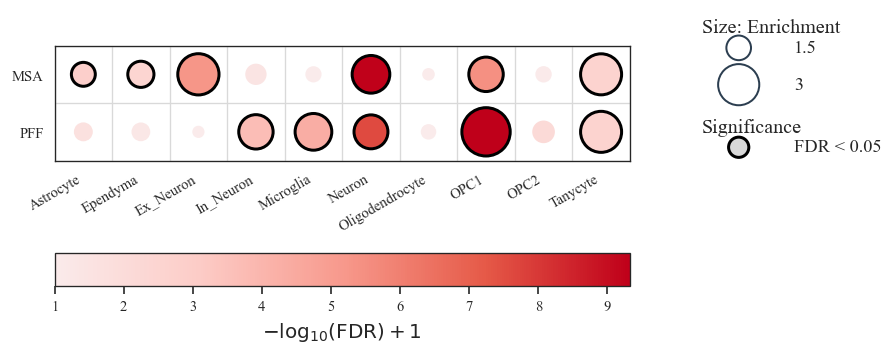

Saved:
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\MSA_PFF_top300_CellType_enrichment\Cell_Type\CellType_HeatmapBubble_MSA_PFF_horizontal_white2red.pdf
C:\Users\forge\Desktop\Documents\8. GCI vs PFF Spread model\Code\Figures Python\Results\MSA_PFF_top300_CellType_enrichment\Cell_Type\CellType_HeatmapBubble_MSA_PFF_horizontal_white2red.png


In [3]:

# -------------------------
# Run
# -------------------------
plot_special_heatmap_bubble_from_excel(
    file_xlsx=file_xlsx,
    out_dir=out_dir,
    sheet_left="MSA",
    sheet_right="PFF",
    rownames=("MSA", "PFF"),
    save_prefix="CellType_HeatmapBubble_MSA_PFF_horizontal_white2red"
)